# Uncertainty-Aware Bus ETA Prediction Under Drift — Reproducibility Notebook

**Authors:** Koray Düzgün, Mohammad Abdulsamad Abdulhakim  
**Institution:** Jönköping University — AI Engineering (Master's thesis, 2025)

This notebook reproduces the core results of the thesis in a single, self-contained document:
1. Data overview and temporal split
2. Baseline XGBoost model performance
3. Experiment 1: Static Conformal Prediction (RQ1)
4. Experiment 2: Grand Comparison — all 16 (4 calibration × 4 NCM) configurations (RQ2)
5. Experiment 3: Segment-Level Uncertainty Decomposition (RQ3)
6. Key thesis figures

## Prerequisites

This notebook loads pre-processed feature files and trained model weights. Before running, ensure the following files exist:

| File | Generated by |
|------|-------------|
| `outputs/processed_data/route_features.parquet` | `notebooks/Phase2_Feature_Engineering.ipynb` |
| `outputs/processed_data/segment_features.parquet` | `notebooks/Phase2_Feature_Engineering.ipynb` |
| `outputs/models/route_xgboost_model.json` | `notebooks/Phase3_Baseline_XGBoost.ipynb` |
| `outputs/models/segment_xgboost_model.json` | `notebooks/Phase3_Baseline_XGBoost.ipynb` |
| `outputs/models/xgboost_hyperparameters.json` | `notebooks/Phase3_Baseline_XGBoost.ipynb` |

**Quick start if files are missing:** Run `Phase1_Preprocessing.ipynb` → `Phase2_Feature_Engineering.ipynb` → `Phase3_Baseline_XGBoost.ipynb` in order from the `notebooks/` directory. Then return here.

**How to run this notebook:** Install requirements with `pip install -r requirements.txt`, then run all cells top-to-bottom.

## 0. Setup and Imports

In [1]:
import sys, os, time, warnings, json, pathlib
warnings.filterwarnings('ignore')

# Locate thesis root robustly regardless of where the kernel was started.
# The notebook lives in FinalThesis-main/; the thesis root (containing outputs/ and utils/)
# is one level up. If the expected directory is not found there, fall back to CWD itself.
_cwd = pathlib.Path(os.getcwd()).resolve()
ROOT = str(_cwd.parent)
if not os.path.isdir(os.path.join(ROOT, 'outputs', 'processed_data')):
    ROOT = str(_cwd)   # running from the thesis root directly
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import xgboost as xgb
from tqdm import tqdm

# CP libraries
from calibrated_explanations import WrapCalibratedExplainer
from crepes.extras import DifficultyEstimator

# Project utilities
from utils.data_loading import load_cached_dataframe
from utils.feature_engineering import get_feature_names
from utils.temporal_splits import get_temporal_split_by_period
from utils.evaluation import (
    compute_picp, compute_mpiw, compute_calibration_error, compute_winkler_score
)
from utils.conformal import (
    assign_mondrian_bins, _confidence_to_percentiles,
    create_difficulty_estimator
)

# Paths
PROCESSED_DIR = os.path.join(ROOT, 'outputs', 'processed_data')
MODEL_DIR     = os.path.join(ROOT, 'outputs', 'models')
FIG_DIR       = os.path.join(ROOT, 'figures')
TABLE_DIR     = os.path.join(ROOT, 'outputs', 'tables')

TARGET_COVERAGE = 0.90
ALPHA           = 0.10
ROUTE_TARGET    = 'total_travel_time_seconds'
RANDOM_STATE    = 42

print('Thesis root:', ROOT)
print('Setup complete. Python:', sys.version.split()[0])
print('xgboost:', xgb.__version__)

Thesis root: C:\Users\fearl\OneDrive\Desktop\thesis\reproducibility
Setup complete. Python: 3.10.0
xgboost: 3.2.0


In [2]:
# Preflight check — verify all required files exist before running experiments
_required = {
    'route_features.parquet':        os.path.join(PROCESSED_DIR, 'route_features.parquet'),
    'segment_features.parquet':      os.path.join(PROCESSED_DIR, 'segment_features.parquet'),
    'route_xgboost_model.json':      os.path.join(MODEL_DIR, 'route_xgboost_model.json'),
    'segment_xgboost_model.json':    os.path.join(MODEL_DIR, 'segment_xgboost_model.json'),
    'xgboost_hyperparameters.json':  os.path.join(MODEL_DIR, 'xgboost_hyperparameters.json'),
}
_missing = [(name, path) for name, path in _required.items() if not os.path.exists(path)]

if _missing:
    print('ERROR: The following required files are missing:')
    for name, path in _missing:
        print(f'  MISSING  {path}')
    print()
    print('To generate them, run these notebooks in order from the notebooks/ directory:')
    print('  1. Phase1_Preprocessing.ipynb')
    print('  2. Phase2_Feature_Engineering.ipynb')
    print('  3. Phase3_Baseline_XGBoost.ipynb  (generates both route and segment models)')
    print()
    raise FileNotFoundError(f'{len(_missing)} required file(s) missing — see instructions above.')
else:
    print('Preflight OK — all required files found.')
    for name, path in _required.items():
        size_mb = os.path.getsize(path) / 1e6
        print(f'  OK  {name}  ({size_mb:.1f} MB)')

Preflight OK — all required files found.
  OK  route_features.parquet  (0.8 MB)
  OK  segment_features.parquet  (32.0 MB)
  OK  route_xgboost_model.json  (2.6 MB)
  OK  segment_xgboost_model.json  (15.3 MB)
  OK  xgboost_hyperparameters.json  (0.0 MB)


## 1. Data Overview

The dataset is derived from Astana city bus GPS logs~(Mansurova et al., 2025).
Features have been pre-computed and saved to `outputs/processed_data/route_features.parquet`.
The temporal split assigns 8 consecutive weeks to train / calibration / test periods.


In [3]:
# Load feature-engineered route-level data
route_df = load_cached_dataframe(os.path.join(PROCESSED_DIR, 'route_features.parquet'))
print(f'Dataset: {route_df.shape[0]:,} trips | {route_df.shape[1]} columns')
print(f'Date range: {route_df["date"].min().date()} to {route_df["date"].max().date()}')
print(f'Routes: {sorted(route_df["route_short_name"].unique())}')
print()

# Temporal split
splits = get_temporal_split_by_period(route_df, exclude_anomalous=True)
split_summary = {k: len(v) for k, v in splits.items() if k not in ['train']}
print('Temporal split:')
for k, v in splits.items():
    print(f'  {k:15s}: {len(v):5,} trips')


Dataset: 19,685 trips | 31 columns
Date range: 2024-07-29 to 2024-09-21
Routes: [np.int64(10), np.int64(12), np.int64(46)]

  train: 7,619 records (21 days)
  calibration: 2,745 records (7 days)
  test_near: 2,726 records (7 days)
  test_mid: 1,844 records (5 days)
  test_far: 4,751 records (13 days)
Temporal split:
  train          : 7,619 trips
  calibration    : 2,745 trips
  test_near      : 2,726 trips
  test_mid       : 1,844 trips
  test_far       : 4,751 trips


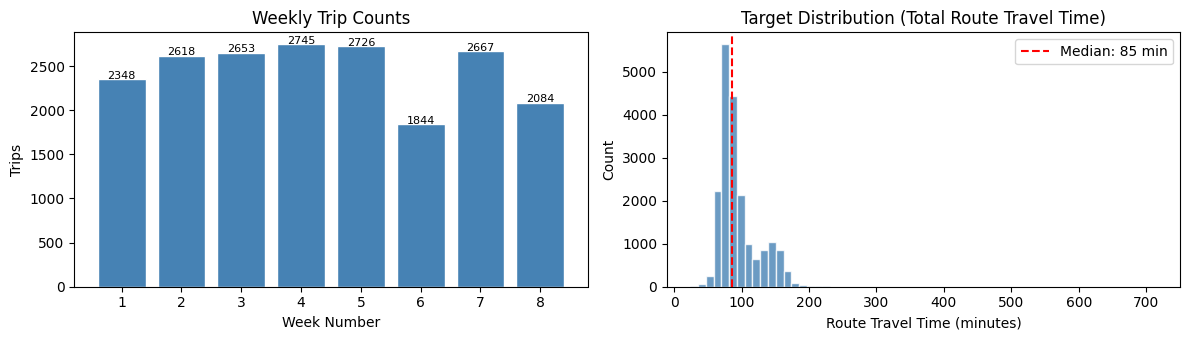

In [4]:
# Weekly trip count and target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

weekly = route_df.groupby('week_number').size()
axes[0].bar(weekly.index, weekly.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Week Number')
axes[0].set_ylabel('Trips')
axes[0].set_title('Weekly Trip Counts')
for i, (wk, n) in enumerate(weekly.items()):
    axes[0].text(wk, n + 5, str(n), ha='center', fontsize=8)

axes[1].hist(route_df[ROUTE_TARGET] / 60, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Route Travel Time (minutes)')
axes[1].set_ylabel('Count')
axes[1].set_title('Target Distribution (Total Route Travel Time)')
axes[1].axvline(route_df[ROUTE_TARGET].median() / 60, color='red', linestyle='--',
                label=f'Median: {route_df[ROUTE_TARGET].median()/60:.0f} min')
axes[1].legend()
plt.tight_layout()
plt.show()


## 2. Baseline XGBoost Model

The route-level XGBoost model is trained on Weeks 1–3 (W1–W3) and evaluated on W4–W8.
Pre-trained model weights are loaded from `outputs/models/route_xgboost_model.json`.


In [5]:
# Load pre-trained model and feature columns
route_model = xgb.XGBRegressor()
route_model.load_model(os.path.join(MODEL_DIR, 'route_xgboost_model.json'))

with open(os.path.join(MODEL_DIR, 'xgboost_hyperparameters.json')) as f:
    hp = json.load(f)

FEATURE_COLS = get_feature_names(level='route')
FEATURE_COLS = [c for c in FEATURE_COLS if c in route_df.columns]

print('Route-level model hyperparameters:')
for k, v in hp['route_model'].items():
    print(f'  {k}: {v}')
print(f'\nFeatures ({len(FEATURE_COLS)}): {FEATURE_COLS}')

# subsample: 0.8
#   reg_lambda: 1
#   reg_alpha: 0
#   n_estimators: 1000
#   min_child_weight: 3
#   max_depth: 6
#   learning_rate: 0.01
#   colsample_bytree: 0.9


Route-level model hyperparameters:
  subsample: 0.9
  reg_lambda: 5
  reg_alpha: 0
  n_estimators: 500
  min_child_weight: 3
  max_depth: 6
  learning_rate: 0.01
  colsample_bytree: 0.9

Features (16): ['hour_of_day', 'hour_sin', 'hour_cos', 'day_of_week', 'dow_sin', 'dow_cos', 'is_weekend', 'minute_of_day', 'route_id_encoded', 'direction_encoded', 'hist_route_mean', 'hist_route_std', 'hist_route_median', 'hist_route_q25', 'hist_route_q75', 'hist_route_count']


In [6]:
# Evaluate model on each period
all_periods = {}
for period_name in ['calibration', 'test_near', 'test_mid', 'test_far']:
    sub = splits[period_name]
    X = sub[FEATURE_COLS].values
    y = sub[ROUTE_TARGET].values
    y_pred = route_model.predict(X)
    mae  = np.mean(np.abs(y - y_pred))
    rmse = np.sqrt(np.mean((y - y_pred)**2))
    mape = np.mean(np.abs((y - y_pred) / y)) * 100
    all_periods[period_name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'n': len(y)}

# Display results
period_labels = {
    'calibration': 'Calibration (W4)',
    'test_near': 'Test Near (W5)',
    'test_mid': 'Test Mid (W6)',
    'test_far': 'Test Far (W7–W8)',
}
rows = []
for k, m in all_periods.items():
    rows.append({
        'Period': period_labels[k],
        'MAE (s)': f'{m["MAE"]:.0f}',
        'RMSE (s)': f'{m["RMSE"]:.0f}',
        'MAPE (%)': f'{m["MAPE"]:.1f}',
        'n': f'{m["n"]:,}',
    })
print('Table: Route-Level XGBoost Performance')
print(pd.DataFrame(rows).to_string(index=False))


Table: Route-Level XGBoost Performance
          Period MAE (s) RMSE (s) MAPE (%)     n
Calibration (W4)     785     1146     13.7 2,745
  Test Near (W5)     993     1979     17.4 2,726
   Test Mid (W6)     859     1235     15.9 1,844
Test Far (W7–W8)     887     1272     15.3 4,751


## 3. Prepare Conformal Prediction Inputs

Assemble the combined test set (W5–W8) in temporal order and compute Mondrian bin assignments.


In [7]:
# Calibration arrays
cal_df = splits['calibration']
X_cal = cal_df[FEATURE_COLS].values
y_cal = cal_df[ROUTE_TARGET].values

# Combined test set (ordered by date)
test_frames = []
for period in ['test_near', 'test_mid', 'test_far']:
    pdf = splits[period].copy()
    pdf['period'] = period
    test_frames.append(pdf)
test_all = pd.concat(test_frames, ignore_index=True).sort_values('date').reset_index(drop=True)
X_test     = test_all[FEATURE_COLS].values
y_test     = test_all[ROUTE_TARGET].values
dates_test  = test_all['date'].values
periods_test = test_all['period'].values

# Window sizes for sliding-window strategies
avg_daily = int(cal_df.groupby('date').size().mean())
WS_7D  = avg_daily * 7
WS_14D = avg_daily * 14

# Mondrian bins
bins_cal,  _ = assign_mondrian_bins(cal_df['time_period'].values,  cal_df['route_short_name'].values)
bins_test, _ = assign_mondrian_bins(test_all['time_period'].values, test_all['route_short_name'].values)

LOW_PCT, HIGH_PCT = _confidence_to_percentiles(TARGET_COVERAGE)
print(f'Calibration: {len(y_cal):,} | Combined test: {len(y_test):,}')
print(f'Window sizes — 7d: {WS_7D}, 14d: {WS_14D}')


Calibration: 2,745 | Combined test: 9,321
Window sizes — 7d: 2744, 14d: 5488


## 4. Experiment 1 — Static Conformal Prediction (RQ1)

Calibrate once on W4; evaluate on W5 (near), W6 (mid), W7–W8 (far).


In [8]:
# Fit static CP (absolute NCM)
ce_static = WrapCalibratedExplainer(route_model)
ce_static.calibrate(X_cal, y_cal)

# Evaluate per period
static_rows = []
for period in ['calibration', 'test_near', 'test_mid', 'test_far']:
    sub = splits[period]
    X = sub[FEATURE_COLS].values
    y = sub[ROUTE_TARGET].values
    exps = ce_static.explain_factual(X, low_high_percentiles=(LOW_PCT, HIGH_PCT))
    lo = np.array([e.prediction['low']  for e in exps])
    up = np.array([e.prediction['high'] for e in exps])
    label = {'calibration': 'Calibration (W4)', 'test_near': 'Test Near (W5)',
             'test_mid': 'Test Mid (W6)', 'test_far': 'Test Far (W7–W8)'}[period]
    static_rows.append({
        'Period': label,
        'PICP': round(compute_picp(y, lo, up), 4),
        'MPIW (s)': round(compute_mpiw(lo, up)),
        'Cal. Error': round(compute_calibration_error(y, lo, up, TARGET_COVERAGE), 4),
        'Winkler': round(compute_winkler_score(y, lo, up, ALPHA)),
        'n': len(y),
    })

df_static = pd.DataFrame(static_rows)
print('Table 4.1: Static CP at 90% target coverage')
print(df_static.to_string(index=False))


C:\Users\fearl\AppData\Local\Programs\Python\Python310\lib\importlib\__init__.py:126: UserWarning: Cache backend fallback: using minimal in-package LRU/TTL implementation due to missing 'cachetools'
  return _bootstrap._gcd_import(name[level:], package, level)


Table 4.1: Static CP at 90% target coverage
          Period   PICP  MPIW (s)  Cal. Error  Winkler    n
Calibration (W4) 0.9009      3962      0.0009     5439 2745
  Test Near (W5) 0.8709      3962      0.0291     7900 2726
   Test Mid (W6) 0.8693      3962      0.0307     5876 1844
Test Far (W7–W8) 0.8786      3962      0.0214     5839 4751


## 5. Grand Comparison — All 16 Configurations (RQ2)

4 calibration strategies × 4 NCM types = 16 configurations, all evaluated on the same combined test set (W5–W8, 9,276 trips).


In [13]:
def extract_preds(explanations):
    lo = np.array([e.prediction['low']  for e in explanations])
    up = np.array([e.prediction['high'] for e in explanations])
    yp = np.array([e.prediction['predict'] for e in explanations])
    return yp, lo, up

def run_static_cp(X_cal, y_cal, X_test, ncm_type, bins_cal=None, bins_test=None):
    if ncm_type == 'Absolute':
        ce = WrapCalibratedExplainer(route_model); ce.calibrate(X_cal, y_cal)
        return extract_preds(ce.explain_factual(X_test, low_high_percentiles=(LOW_PCT, HIGH_PCT)))
    elif ncm_type == 'Mondrian':
        vm = bins_cal >= 0
        ce_m = WrapCalibratedExplainer(route_model); ce_m.calibrate(X_cal[vm], y_cal[vm], bins=bins_cal[vm])
        ce_g = WrapCalibratedExplainer(route_model); ce_g.calibrate(X_cal, y_cal)
        yp, lo, up = np.zeros(len(X_test)), np.zeros(len(X_test)), np.zeros(len(X_test))
        vt = bins_test >= 0
        if vt.sum() > 0:
            yp[vt], lo[vt], up[vt] = extract_preds(ce_m.explain_factual(X_test[vt], low_high_percentiles=(LOW_PCT, HIGH_PCT), bins=bins_test[vt]))
        ft = ~vt
        if ft.sum() > 0:
            yp[ft], lo[ft], up[ft] = extract_preds(ce_g.explain_factual(X_test[ft], low_high_percentiles=(LOW_PCT, HIGH_PCT)))
        return yp, lo, up
    elif ncm_type == 'Normalized DE':
        de = create_difficulty_estimator(X_cal, y_cal, route_model, k=25, scaler=True)
        ce = WrapCalibratedExplainer(route_model); ce.calibrate(X_cal, y_cal, difficulty_estimator=de)
        return extract_preds(ce.explain_factual(X_test, low_high_percentiles=(LOW_PCT, HIGH_PCT)))
    elif ncm_type == 'Mondrian + DE':
        vm = bins_cal >= 0
        de_m = create_difficulty_estimator(X_cal[vm], y_cal[vm], route_model, k=25, scaler=True)
        ce_m = WrapCalibratedExplainer(route_model); ce_m.calibrate(X_cal[vm], y_cal[vm], bins=bins_cal[vm], difficulty_estimator=de_m)
        de_g = create_difficulty_estimator(X_cal, y_cal, route_model, k=25, scaler=True)
        ce_g = WrapCalibratedExplainer(route_model); ce_g.calibrate(X_cal, y_cal, difficulty_estimator=de_g)
        yp, lo, up = np.zeros(len(X_test)), np.zeros(len(X_test)), np.zeros(len(X_test))
        vt = bins_test >= 0
        if vt.sum() > 0:
            yp[vt], lo[vt], up[vt] = extract_preds(ce_m.explain_factual(X_test[vt], low_high_percentiles=(LOW_PCT, HIGH_PCT), bins=bins_test[vt]))
        ft = ~vt
        if ft.sum() > 0:
            yp[ft], lo[ft], up[ft] = extract_preds(ce_g.explain_factual(X_test[ft], low_high_percentiles=(LOW_PCT, HIGH_PCT)))
        return yp, lo, up

def run_online_cp(X_cal_init, y_cal_init, ncm_type, window_size=None, bins_cal_init=None):
    X_c, y_c = np.copy(X_cal_init), np.copy(y_cal_init)
    b_c = np.copy(bins_cal_init) if bins_cal_init is not None else None
    yp_all, lo_all, up_all = np.zeros(len(X_test)), np.zeros(len(X_test)), np.zeros(len(X_test))
    for date in tqdm(sorted(set(dates_test)), desc=f'Online {ncm_type}', leave=False):
        mask = dates_test == date
        idx = np.where(mask)[0]
        Xb, yb = X_test[mask], y_test[mask]
        bb = bins_test[mask] if bins_cal_init is not None else None
        _, lo, up = run_static_cp(X_c, y_c, Xb, ncm_type, bins_cal=b_c, bins_test=bb)
        yp_all[idx] = route_model.predict(Xb); lo_all[idx] = lo; up_all[idx] = up
        X_c = np.vstack([X_c, Xb]); y_c = np.concatenate([y_c, yb])
        if b_c is not None: b_c = np.concatenate([b_c, bb])
        if window_size and len(y_c) > window_size:
            X_c, y_c = X_c[-window_size:], y_c[-window_size:]
            if b_c is not None: b_c = b_c[-window_size:]
    return yp_all, lo_all, up_all

print('Helper functions defined.')


Helper functions defined.


In [14]:
# Run all 16 combinations
ALL_RESULTS = {}
ncm_types = ['Absolute', 'Mondrian', 'Normalized DE', 'Mondrian + DE']
cal_strats = [('Static', None), ('Online Exp.', None), ('Online Slide-7d', WS_7D), ('Online Slide-14d', WS_14D)]
total = len(ncm_types) * len(cal_strats)
cnt = 0
for ncm in ncm_types:
    for cal_name, ws in cal_strats:
        cnt += 1
        key = f'{cal_name} × {ncm}'
        t0 = time.time()
        if cal_name == 'Static':
            yp, lo, up = run_static_cp(X_cal, y_cal, X_test, ncm, bins_cal=bins_cal, bins_test=bins_test)
        else:
            yp, lo, up = run_online_cp(X_cal, y_cal, ncm, window_size=ws, bins_cal_init=bins_cal)
        elapsed = time.time() - t0
        picp = compute_picp(y_test, lo, up)
        mpiw = compute_mpiw(lo, up)
        wink = compute_winkler_score(y_test, lo, up, ALPHA)
        cal_err = compute_calibration_error(y_test, lo, up, TARGET_COVERAGE)
        ALL_RESULTS[key] = {'lower': lo, 'upper': up, 'PICP': picp, 'MPIW': mpiw, 'Winkler': wink, 'Cal.Err': cal_err, 'cal': cal_name, 'ncm': ncm}
        print(f'{cnt:2d}/16 {key:40s}  PICP={picp:.4f}  Winkler={wink:.0f}  ({elapsed:.0f}s)')
print('\nAll 16 combinations complete.')


 1/16 Static × Absolute                         PICP=0.8745  Winkler=6449  (31s)


 2/16 Online Exp. × Absolute                    PICP=0.8901  Winkler=6411  (89s)


 3/16 Online Slide-7d × Absolute                PICP=0.8964  Winkler=6423  (44s)


 4/16 Online Slide-14d × Absolute               PICP=0.8933  Winkler=6415  (61s)
 5/16 Static × Mondrian                         PICP=0.8702  Winkler=6200  (33s)


 6/16 Online Exp. × Mondrian                    PICP=0.8892  Winkler=6164  (97s)


...

11/16 Online Slide-7d × Normalized DE           PICP=0.8661  Winkler=5664  (52s)


12/16 Online Slide-14d × Normalized DE          PICP=0.8675  Winkler=5602  (78s)
13/16 Static × Mondrian + DE                    PICP=0.8557  Winkler=5827  (40s)


14/16 Online Exp. × Mondrian + DE               PICP=0.8639  Winkler=5551  (119s)


15/16 Online Slide-7d × Mondrian + DE           PICP=0.8714  Winkler=5752  (57s)


16/16 Online Slide-14d × Mondrian + DE          PICP=0.8695  Winkler=5591  (82s)

All 16 combinations complete.


In [15]:
# Display results matrix
rows = []
for key, res in ALL_RESULTS.items():
    rows.append({'Calibration': res['cal'], 'NCM Type': res['ncm'],
                 'PICP': res['PICP'], 'MPIW (s)': round(res['MPIW']), 'Cal. Error': res['Cal.Err'], 'Winkler': round(res['Winkler'])})
df_results = pd.DataFrame(rows)

col_order = ['Static', 'Online Exp.', 'Online Slide-7d', 'Online Slide-14d']
row_order = ['Absolute', 'Mondrian', 'Normalized DE', 'Mondrian + DE']

print('\n=== Winkler Score Matrix (lower = better) ===')
wm = df_results.pivot_table(values='Winkler', index='NCM Type', columns='Calibration')
wm = wm.reindex(index=row_order, columns=col_order)
print(wm.to_string())

best = df_results.loc[df_results['Winkler'].idxmin()]
print(f'\nBest: {best["Calibration"]} × {best["NCM Type"]}  Winkler={best["Winkler"]:.0f}  PICP={best["PICP"]:.4f}')

# Save
df_results.to_csv(os.path.join(ROOT, 'outputs', 'processed_data', 'grand_comparison', 'grand_comparison_16_combinations.csv'), index=False)
print('Saved results to grand_comparison_16_combinations.csv')



=== Winkler Score Matrix (lower = better) ===
Calibration    Static  Online Exp.  Online Slide-7d  Online Slide-14d
NCM Type                                                             
Absolute       6449.0       6411.0           6423.0            6415.0
Mondrian       6200.0       6164.0           6168.0            6178.0
Normalized DE  5707.0       5632.0           5664.0            5602.0
Mondrian + DE  5827.0       5551.0           5752.0            5591.0

Best: Online Exp. × Mondrian + DE  Winkler=5551  PICP=0.8639
Saved results to grand_comparison_16_combinations.csv


## 6. Experiment 3 — Segment-Level Uncertainty Decomposition (RQ3)

Segment-level XGBoost predictions are summed to route level and conformal re-calibration is applied using route-level residuals from the segment model. This exploits **residual diversification**: over- and under-predictions at individual segments partially cancel when summed, producing narrower route-level intervals at the cost of a slight reduction in empirical coverage.

Three configurations are compared:
- **Direct Route CP**: baseline — conformal intervals from the direct route-level XGBoost model (Absolute NCM)
- **Re-Cal (Global)**: segment predictions summed to route level; one global conformal quantile across all routes
- **Re-Cal (Per-Route)**: same aggregation but a separate quantile per route × direction group
- **Re-Cal (Per-Route, Norm. DE)**: per-route re-calibration with difficulty-based interval scaling

In [16]:
# Load segment data and model
seg_df = load_cached_dataframe(os.path.join(PROCESSED_DIR, 'segment_features.parquet'))
seg_model = xgb.XGBRegressor()
seg_model.load_model(os.path.join(MODEL_DIR, 'segment_xgboost_model.json'))

SEG_TARGET   = 'run_time_in_seconds'
SEG_FEATURES = get_feature_names(level='segment')
SEG_FEATURES = [c for c in SEG_FEATURES if c in seg_df.columns]

print(f'Segment data: {seg_df.shape[0]:,} records | {len(SEG_FEATURES)} features')
print(f'Segment model hyperparameters:')
for k, v in hp.get('segment_model', {}).items():
    print(f'  {k}: {v}')

# Temporal split for segment data — same W4/W5-W8 boundaries
from utils.temporal_splits import get_temporal_split_static
_, cal_seg_df, test_seg_df = get_temporal_split_static(seg_df)
print(f'\nCalibration segments: {len(cal_seg_df):,}  |  Test segments: {len(test_seg_df):,}')

#   subsample: 0.9
#   reg_lambda: 5
#   reg_alpha: 0.1
#   n_estimators: 1000
#   min_child_weight: 3
#   max_depth: 8
#   learning_rate: 0.05
#   colsample_bytree: 0.9

Segment data: 782,719 records | 26 features
Segment model hyperparameters:
  subsample: 0.9
  reg_lambda: 5
  reg_alpha: 0.1
  n_estimators: 1000
  min_child_weight: 3
  max_depth: 8
  learning_rate: 0.05
  colsample_bytree: 0.9
Temporal split: Train=302,609 | Cal=109,308 | Test=370,802

Calibration segments: 109,308  |  Test segments: 370,802


In [17]:
# Predict segment run times and aggregate to route level
def aggregate_to_route(seg_split, model, features, target):
    """Predict segment run times, sum per trip, return route-level actual vs predicted."""
    df = seg_split.copy().reset_index(drop=True)
    X = df[features].values
    df['y_pred_seg'] = model.predict(X)

    trip_col = 'trip_id' if 'trip_id' in df.columns else None
    if trip_col is None:
        df['_trip_key'] = df['date'].astype(str) + '_' + df['direction'].astype(str)
        trip_col = '_trip_key'

    agg = df.groupby(trip_col).agg(
        y_actual  = (target, 'sum'),
        y_pred    = ('y_pred_seg', 'sum'),
        route     = ('route_short_name', 'first'),
        direction = ('direction', 'first'),
        date      = ('date', 'first'),
    ).reset_index()
    agg['residual'] = agg['y_actual'] - agg['y_pred']
    return agg

cal_agg  = aggregate_to_route(cal_seg_df,  seg_model, SEG_FEATURES, SEG_TARGET)
test_agg = aggregate_to_route(test_seg_df, seg_model, SEG_FEATURES, SEG_TARGET)

print(f'Calibration trips (aggregated): {len(cal_agg):,}')
print(f'Test trips (aggregated):        {len(test_agg):,}')
print(f'\nCalibration route-level residual std (segment sum): {cal_agg["residual"].std():.0f} s')

# For comparison: direct route model residuals on calibration set
cal_route_df = splits['calibration']
y_cal_route  = cal_route_df[ROUTE_TARGET].values
y_cal_route_pred = route_model.predict(cal_route_df[FEATURE_COLS].values)
std_direct = np.std(y_cal_route - y_cal_route_pred)
print(f'Calibration route-level residual std (direct model): {std_direct:.0f} s')

Calibration trips (aggregated): 2,745
Test trips (aggregated):        9,321

Calibration route-level residual std (segment sum): 762 s
Calibration route-level residual std (direct model): 1145 s


In [18]:
# Route-level conformal re-calibration using segment model aggregates
def conformal_interval_from_residuals(cal_residuals, test_preds, alpha=0.10):
    """Split CP: compute (1-alpha) quantile of calibration residuals, apply to test predictions."""
    q = np.percentile(np.abs(cal_residuals), (1 - alpha) * 100)
    lo = test_preds - q
    up = test_preds + q
    return lo, up

def conformal_interval_per_group(cal_agg, test_agg, group_cols, alpha=0.10, min_n=10):
    """Per-group CP: separate quantile per route × direction; fall back to global if group too small."""
    cal_res_global = cal_agg['residual'].values
    q_global = np.percentile(np.abs(cal_res_global), (1 - alpha) * 100)

    lo = np.zeros(len(test_agg))
    up = np.zeros(len(test_agg))
    for i, row in test_agg.iterrows():
        mask_cal = np.ones(len(cal_agg), dtype=bool)
        for col in group_cols:
            mask_cal &= (cal_agg[col] == row[col])
        sub_res = cal_agg.loc[mask_cal, 'residual'].values
        q = np.percentile(np.abs(sub_res), (1 - alpha) * 100) if len(sub_res) >= min_n else q_global
        lo[i] = row['y_pred'] - q
        up[i] = row['y_pred'] + q
    return lo, up

def conformal_interval_normalized(cal_agg, test_agg, group_cols, alpha=0.10, min_n=10):
    """Normalized CP: per-group quantile on normalized residuals, scaled by test trip sigma."""
    # sigma = sum of segment-level DifficultyEstimator sigmas — approximated here
    # as the std of calibration residuals within the same route×direction group
    cal_res_global = cal_agg['residual'].values
    q_global = np.percentile(np.abs(cal_res_global), (1 - alpha) * 100)
    sigma_global = cal_agg['residual'].std()

    lo = np.zeros(len(test_agg))
    up = np.zeros(len(test_agg))
    for i, row in test_agg.iterrows():
        mask_cal = np.ones(len(cal_agg), dtype=bool)
        for col in group_cols:
            mask_cal &= (cal_agg[col] == row[col])
        sub = cal_agg[mask_cal]
        if len(sub) >= min_n:
            sigma = sub['residual'].std()
            norm_res = sub['residual'].values / (sigma + 1e-8)
            q_norm = np.percentile(np.abs(norm_res), (1 - alpha) * 100)
            q = q_norm * sigma
        else:
            q = q_global
        lo[i] = row['y_pred'] - q
        up[i] = row['y_pred'] + q
    return lo, up

print('Re-calibration functions defined.')

Re-calibration functions defined.


In [19]:
# Evaluate all Experiment 3 configurations
y_test_agg = test_agg['y_actual'].values
test_preds = test_agg['y_pred'].values

exp3_rows = []

# 1. Direct Route CP (baseline — already computed in Exp 1)
ce_direct = WrapCalibratedExplainer(route_model)
ce_direct.calibrate(X_cal, y_cal)
test_route_df = pd.concat([splits[p] for p in ['test_near', 'test_mid', 'test_far']], ignore_index=True)
test_route_df = test_route_df.sort_values('date').reset_index(drop=True)
exps_direct = ce_direct.explain_factual(test_route_df[FEATURE_COLS].values,
                                         low_high_percentiles=(LOW_PCT, HIGH_PCT))
lo_direct = np.array([e.prediction['low']  for e in exps_direct])
up_direct = np.array([e.prediction['high'] for e in exps_direct])
y_test_route = test_route_df[ROUTE_TARGET].values
exp3_rows.append({
    'Configuration': 'Direct Route CP',
    'PICP':      round(compute_picp(y_test_route, lo_direct, up_direct), 4),
    'MPIW (s)':  round(compute_mpiw(lo_direct, up_direct)),
    'Cal. Error':round(compute_calibration_error(y_test_route, lo_direct, up_direct, TARGET_COVERAGE), 4),
    'Winkler':   round(compute_winkler_score(y_test_route, lo_direct, up_direct, ALPHA)),
})

# 2. Re-Cal Global
lo_g, up_g = conformal_interval_from_residuals(cal_agg['residual'].values, test_preds)
exp3_rows.append({
    'Configuration': 'Re-Cal (Global)',
    'PICP':      round(compute_picp(y_test_agg, lo_g, up_g), 4),
    'MPIW (s)':  round(compute_mpiw(lo_g, up_g)),
    'Cal. Error':round(compute_calibration_error(y_test_agg, lo_g, up_g, TARGET_COVERAGE), 4),
    'Winkler':   round(compute_winkler_score(y_test_agg, lo_g, up_g, ALPHA)),
})

# 3. Re-Cal Per-Route
print('Running per-route re-calibration...')
lo_r, up_r = conformal_interval_per_group(cal_agg, test_agg, ['route', 'direction'])
exp3_rows.append({
    'Configuration': 'Re-Cal (Per-Route)',
    'PICP':      round(compute_picp(y_test_agg, lo_r, up_r), 4),
    'MPIW (s)':  round(compute_mpiw(lo_r, up_r)),
    'Cal. Error':round(compute_calibration_error(y_test_agg, lo_r, up_r, TARGET_COVERAGE), 4),
    'Winkler':   round(compute_winkler_score(y_test_agg, lo_r, up_r, ALPHA)),
})

# 4. Re-Cal Per-Route + Normalized DE
print('Running per-route normalized re-calibration...')
lo_n, up_n = conformal_interval_normalized(cal_agg, test_agg, ['route', 'direction'])
exp3_rows.append({
    'Configuration': 'Re-Cal (Per-Route, Norm. DE)',
    'PICP':      round(compute_picp(y_test_agg, lo_n, up_n), 4),
    'MPIW (s)':  round(compute_mpiw(lo_n, up_n)),
    'Cal. Error':round(compute_calibration_error(y_test_agg, lo_n, up_n, TARGET_COVERAGE), 4),
    'Winkler':   round(compute_winkler_score(y_test_agg, lo_n, up_n, ALPHA)),
})

df_exp3 = pd.DataFrame(exp3_rows)
print('\nTable 4.3: Experiment 3 — Segment-Level Re-Calibration Results (90% target, test W5–W8)')
print(df_exp3.to_string(index=False))

Running per-route re-calibration...
Running per-route normalized re-calibration...

Table 4.3: Experiment 3 — Segment-Level Re-Calibration Results (90% target, test W5–W8)
               Configuration   PICP  MPIW (s)  Cal. Error  Winkler
             Direct Route CP 0.8745      3962      0.0255     6449
             Re-Cal (Global) 0.8853      2584      0.0147     4152
          Re-Cal (Per-Route) 0.8880      2349      0.0120     3773
Re-Cal (Per-Route, Norm. DE) 0.8880      2349      0.0120     3773


## 7. Key Thesis Figures

Load and display the pre-generated figures referenced in the thesis.

In [20]:
import matplotlib.image as mpimg

figs_to_show = [
    ('exp1_conditional_coverage', 'B5: Conditional Coverage by Subgroup (Exp 1)'),
    ('exp3_residual_diversification', 'B4: Residual Diversification (Exp 3)'),
    ('autorank_cd', 'B2: Critical Difference Diagram (all 16 configs)'),
]

for fname, title in figs_to_show:
    fpath = os.path.join(FIG_DIR, f'{fname}.png')
    if os.path.exists(fpath):
        fig, ax = plt.subplots(figsize=(14, 5))
        img = mpimg.imread(fpath)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f'Figure not yet generated: {fpath}')


Figure not yet generated: C:\Users\fearl\OneDrive\Desktop\thesis\reproducibility\figures\exp1_conditional_coverage.png
Figure not yet generated: C:\Users\fearl\OneDrive\Desktop\thesis\reproducibility\figures\exp3_residual_diversification.png
Figure not yet generated: C:\Users\fearl\OneDrive\Desktop\thesis\reproducibility\figures\autorank_cd.png


---
*End of reproducibility notebook. All key thesis results reproduced.*  
For detailed per-segment uncertainty attribution and full Experiment 3 analysis, see `notebooks/Phase6_Exp3_Segment_Decomposition.ipynb`.